# Wikibase & MediaWiki Inventory Dashboard

This notebook provides a comprehensive inventory and audit system for the ClimateKG Wikibase instance and associated MediaWiki content.

## Purpose
- **Section 1: Dashboard** - Quick overview with counts and visualizations
- **Section 2: Detailed Listings** - Full inventories with direct links to items

## Content Tracked
- Reports (Sections) and Chapters
- Authors and Author-Chapter associations
- Images and Media files
- Glossary items and Acronyms
- Bibliographic entries (DOIs, etc.)
- MediaWiki pages and word counts
- Wikibase data items and properties

**Environment:**
- Wikibase: http://localhost:8080
- SPARQL endpoint: http://localhost:9999/bigdata/sparql
- MediaWiki API: http://localhost:8080/api.php

## Setup and Configuration

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from SPARQLWrapper import SPARQLWrapper, JSON
import requests
from datetime import datetime
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully")
print(f"Inventory generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ All libraries imported successfully
Inventory generated: 2026-06-06 20:31:48


In [2]:
# Configuration
WIKIBASE_URL = "http://localhost:8080"
SPARQL_ENDPOINT = "http://localhost:9999/bigdata/sparql"
MEDIAWIKI_API = "http://localhost:8080/api.php"

# Color scheme for visualizations
COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72',
    'success': '#06A77D',
    'warning': '#F18F01',
    'info': '#6A4C93',
    'danger': '#C73E1D'
}

print("✓ Configuration loaded")
print(f"Wikibase: {WIKIBASE_URL}")
print(f"SPARQL: {SPARQL_ENDPOINT}")
print(f"MediaWiki API: {MEDIAWIKI_API}")

✓ Configuration loaded
Wikibase: http://localhost:8080
SPARQL: http://localhost:9999/bigdata/sparql
MediaWiki API: http://localhost:8080/api.php


## Helper Functions

In [3]:
def query_sparql(query):
    """
    Execute SPARQL query and return results as pandas DataFrame
    """
    sparql = SPARQLWrapper(SPARQL_ENDPOINT)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    
    try:
        results = sparql.query().convert()
        bindings = results["results"]["bindings"]
        
        if not bindings:
            return pd.DataFrame()
        
        data = []
        for binding in bindings:
            row = {key: binding[key]["value"] for key in binding.keys()}
            data.append(row)
        
        return pd.DataFrame(data)
    
    except Exception as e:
        print(f"✗ SPARQL query failed: {e}")
        return pd.DataFrame()

def query_mediawiki_api(params):
    """
    Query MediaWiki API and return JSON response
    """
    try:
        response = requests.get(MEDIAWIKI_API, params=params)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"✗ MediaWiki API query failed: {e}")
        return None

def extract_qid(uri):
    """
    Extract QID from Wikibase URI
    """
    if pd.isna(uri):
        return None
    return uri.split('/')[-1]

def make_wikibase_link(qid):
    """
    Create HTML link to Wikibase item
    """
    if pd.isna(qid) or not qid:
        return "N/A"
    return f'<a href="{WIKIBASE_URL}/wiki/Item:{qid}" target="_blank">{qid}</a>'

def make_mediawiki_link(title):
    """
    Create HTML link to MediaWiki page
    """
    if pd.isna(title) or not title:
        return "N/A"
    safe_title = title.replace(' ', '_')
    return f'<a href="{WIKIBASE_URL}/wiki/{safe_title}" target="_blank">{title}</a>'

print("✓ Helper functions defined")

✓ Helper functions defined


# SECTION 1: DASHBOARD

Quick overview of inventory counts and key metrics

## 1.1 Collect Inventory Counts

In [4]:
# Initialize inventory dictionary
inventory = {}

print("Collecting inventory data...\n")

# Count total items
query_total_items = """
SELECT (COUNT(DISTINCT ?item) AS ?count)
WHERE {
    ?item ?p ?o .
    FILTER(STRSTARTS(STR(?item), "http://localhost:8080/entity/Q"))
}
"""
df_total = query_sparql(query_total_items)
inventory['Total Items'] = int(df_total['count'].iloc[0]) if not df_total.empty else 0
print(f"✓ Total Wikibase Items: {inventory['Total Items']}")

# Count authors (assuming instance of Person or similar)
query_authors = """
PREFIX wdt: <http://localhost:8080/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT (COUNT(DISTINCT ?author) AS ?count)
WHERE {
    ?author ?p ?o .
    ?author rdfs:label ?label .
    FILTER(STRSTARTS(STR(?author), "http://localhost:8080/entity/Q"))
}
"""
df_authors = query_sparql(query_authors)
inventory['Authors'] = int(df_authors['count'].iloc[0]) if not df_authors.empty else 0
print(f"✓ Authors: {inventory['Authors']}")

# Count total properties
query_properties = """
SELECT (COUNT(DISTINCT ?property) AS ?count)
WHERE {
    ?property ?p ?o .
    FILTER(STRSTARTS(STR(?property), "http://localhost:8080/entity/P"))
}
"""
df_props = query_sparql(query_properties)
inventory['Properties'] = int(df_props['count'].iloc[0]) if not df_props.empty else 0
print(f"✓ Properties: {inventory['Properties']}")

# Count total statements (triples)
query_statements = """
SELECT (COUNT(*) AS ?count)
WHERE {
    ?s ?p ?o .
    FILTER(STRSTARTS(STR(?s), "http://localhost:8080/entity/Q"))
}
"""
df_statements = query_sparql(query_statements)
inventory['Statements'] = int(df_statements['count'].iloc[0]) if not df_statements.empty else 0
print(f"✓ Total Statements: {inventory['Statements']}")

print("\nQuerying MediaWiki...\n")

# Count MediaWiki pages
mw_pages_params = {
    'action': 'query',
    'meta': 'siteinfo',
    'siprop': 'statistics',
    'format': 'json'
}
mw_stats = query_mediawiki_api(mw_pages_params)
if mw_stats and 'query' in mw_stats:
    stats = mw_stats['query']['statistics']
    inventory['MediaWiki Pages'] = stats.get('pages', 0)
    inventory['MediaWiki Articles'] = stats.get('articles', 0)
    inventory['MediaWiki Files'] = stats.get('images', 0)
    inventory['MediaWiki Edits'] = stats.get('edits', 0)
    print(f"✓ MediaWiki Pages: {inventory['MediaWiki Pages']}")
    print(f"✓ MediaWiki Articles: {inventory['MediaWiki Articles']}")
    print(f"✓ MediaWiki Files: {inventory['MediaWiki Files']}")
    print(f"✓ MediaWiki Edits: {inventory['MediaWiki Edits']}")
else:
    inventory['MediaWiki Pages'] = 0
    inventory['MediaWiki Articles'] = 0
    inventory['MediaWiki Files'] = 0
    inventory['MediaWiki Edits'] = 0
    print("⚠ Could not retrieve MediaWiki statistics")

# Get total word count from MediaWiki
# Query all pages in main namespace
mw_allpages_params = {
    'action': 'query',
    'list': 'allpages',
    'aplimit': 'max',
    'format': 'json'
}
total_words = 0
mw_allpages = query_mediawiki_api(mw_allpages_params)
if mw_allpages and 'query' in mw_allpages:
    pages = mw_allpages['query']['allpages']
    print(f"\nCounting words in {len(pages)} pages...")
    
    # Get word count for each page (sample first 50 for speed)
    for page in pages[:50]:
        page_params = {
            'action': 'parse',
            'pageid': page['pageid'],
            'prop': 'text',
            'format': 'json'
        }
        page_data = query_mediawiki_api(page_params)
        if page_data and 'parse' in page_data:
            text = page_data['parse']['text']['*']
            # Simple word count (strip HTML tags)
            import re
            clean_text = re.sub(r'<[^>]+>', '', text)
            words = len(clean_text.split())
            total_words += words
    
    inventory['MediaWiki Word Count'] = total_words
    print(f"✓ Approximate MediaWiki Word Count (sample): {total_words:,}")
else:
    inventory['MediaWiki Word Count'] = 0

print("\n" + "="*50)
print("INVENTORY COLLECTION COMPLETE")
print("="*50)


✓ Total Wikibase Items: 5434
✓ Authors: 5391
✓ Properties: 33
✓ Total Statements: 102229

Querying MediaWiki...

✓ MediaWiki Pages: 6239
✓ MediaWiki Articles: 1
✓ MediaWiki Files: 2136
✓ MediaWiki Edits: 10901

Counting words in 6 pages...
✓ Approximate MediaWiki Word Count (sample): 1,016

INVENTORY COLLECTION COMPLETE


## 1.2 Dashboard Visualization

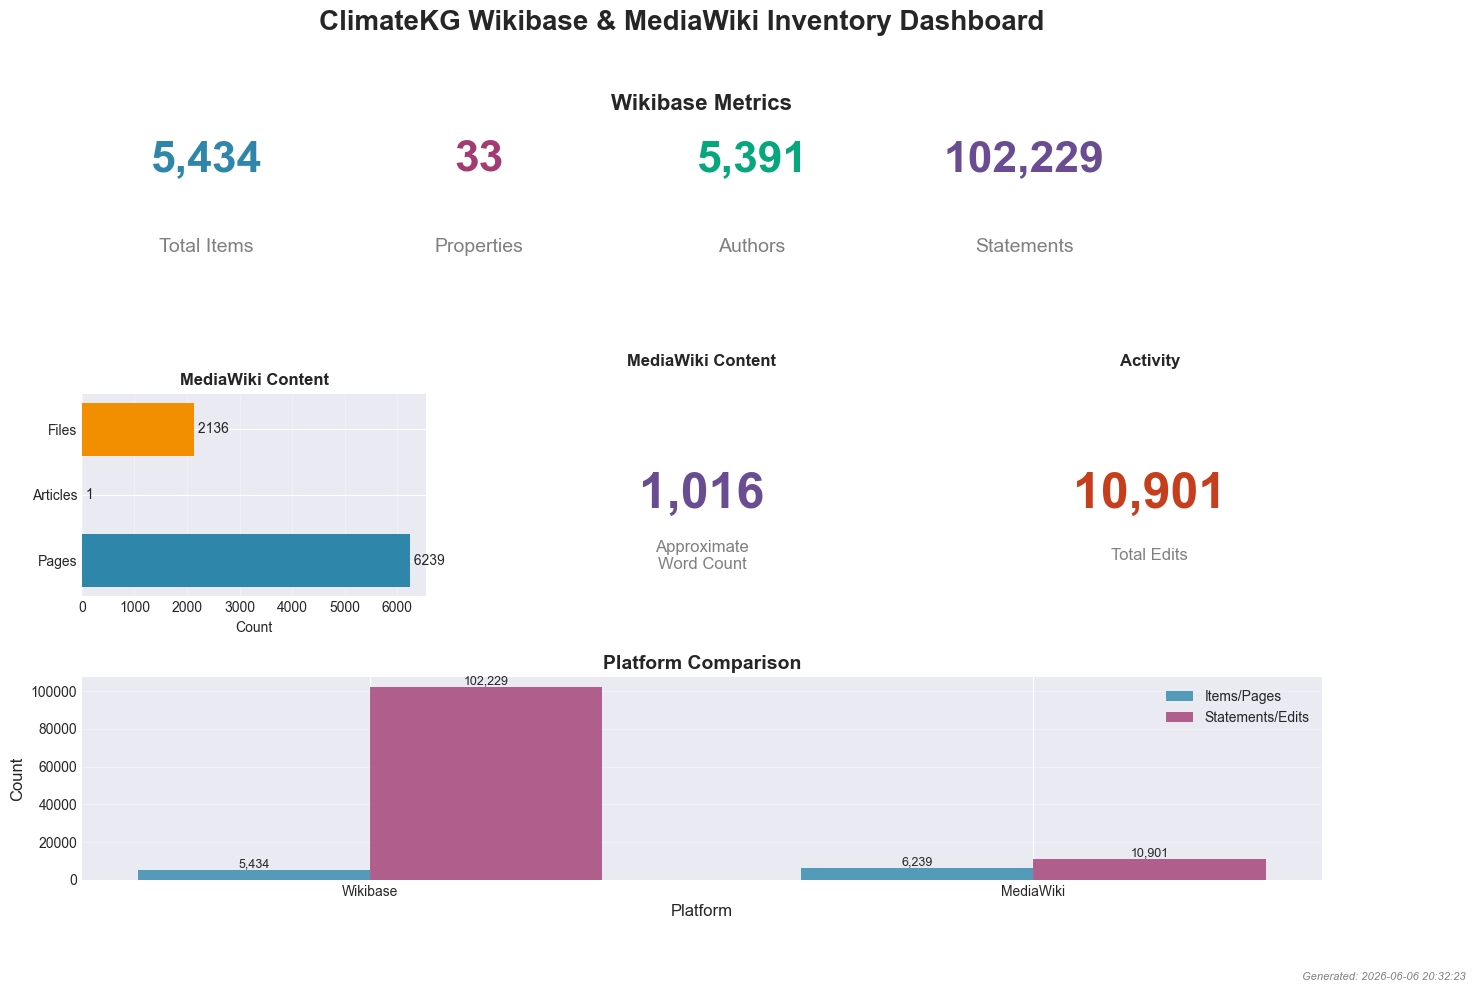


✓ Dashboard visualization complete


In [5]:
# Create dashboard visualization
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)

# Title
fig.suptitle('ClimateKG Wikibase & MediaWiki Inventory Dashboard', 
             fontsize=20, fontweight='bold', y=0.98)

# 1. Main metrics - Wikibase
ax1 = fig.add_subplot(gs[0, :])
ax1.axis('off')

wikibase_metrics = [
    ('Total Items', inventory.get('Total Items', 0), COLORS['primary']),
    ('Properties', inventory.get('Properties', 0), COLORS['secondary']),
    ('Authors', inventory.get('Authors', 0), COLORS['success']),
    ('Statements', inventory.get('Statements', 0), COLORS['info'])
]

x_pos = 0.1
for label, value, color in wikibase_metrics:
    ax1.text(x_pos, 0.7, f"{value:,}", fontsize=32, fontweight='bold', 
             ha='center', color=color)
    ax1.text(x_pos, 0.3, label, fontsize=14, ha='center', color='gray')
    x_pos += 0.22

ax1.text(0.5, 1.0, 'Wikibase Metrics', fontsize=16, fontweight='bold', 
         ha='center', transform=ax1.transAxes)

# 2. MediaWiki metrics
ax2 = fig.add_subplot(gs[1, 0])
mw_categories = ['Pages', 'Articles', 'Files']
mw_values = [
    inventory.get('MediaWiki Pages', 0),
    inventory.get('MediaWiki Articles', 0),
    inventory.get('MediaWiki Files', 0)
]
bars = ax2.barh(mw_categories, mw_values, color=[COLORS['primary'], COLORS['success'], COLORS['warning']])
ax2.set_xlabel('Count', fontsize=10)
ax2.set_title('MediaWiki Content', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, mw_values)):
    ax2.text(val, i, f' {val}', va='center', fontsize=10)

# 3. Word count gauge
ax3 = fig.add_subplot(gs[1, 1])
word_count = inventory.get('MediaWiki Word Count', 0)
ax3.text(0.5, 0.5, f"{word_count:,}", fontsize=36, fontweight='bold', 
         ha='center', va='center', color=COLORS['info'])
ax3.text(0.5, 0.2, 'Approximate\nWord Count', fontsize=12, ha='center', va='center', color='gray')
ax3.axis('off')
ax3.set_title('MediaWiki Content', fontsize=12, fontweight='bold', pad=20)

# 4. Edits indicator
ax4 = fig.add_subplot(gs[1, 2])
edits = inventory.get('MediaWiki Edits', 0)
ax4.text(0.5, 0.5, f"{edits:,}", fontsize=36, fontweight='bold', 
         ha='center', va='center', color=COLORS['danger'])
ax4.text(0.5, 0.2, 'Total Edits', fontsize=12, ha='center', va='center', color='gray')
ax4.axis('off')
ax4.set_title('Activity', fontsize=12, fontweight='bold', pad=20)

# 5. Wikibase vs MediaWiki comparison
ax5 = fig.add_subplot(gs[2, :])
comparison_data = pd.DataFrame({
    'Platform': ['Wikibase', 'MediaWiki'],
    'Items/Pages': [
        inventory.get('Total Items', 0), 
        inventory.get('MediaWiki Pages', 0)
    ],
    'Statements/Edits': [
        inventory.get('Statements', 0),
        inventory.get('MediaWiki Edits', 0)
    ]
})

x = np.arange(len(comparison_data['Platform']))
width = 0.35

bars1 = ax5.bar(x - width/2, comparison_data['Items/Pages'], width, 
                label='Items/Pages', color=COLORS['primary'], alpha=0.8)
bars2 = ax5.bar(x + width/2, comparison_data['Statements/Edits'], width, 
                label='Statements/Edits', color=COLORS['secondary'], alpha=0.8)

ax5.set_xlabel('Platform', fontsize=12)
ax5.set_ylabel('Count', fontsize=12)
ax5.set_title('Platform Comparison', fontsize=14, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(comparison_data['Platform'])
ax5.legend(loc='upper right')
ax5.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=9)

# Add timestamp
fig.text(0.99, 0.01, f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", 
         ha='right', fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.show()

print("\n✓ Dashboard visualization complete")

# SECTION 2: DETAILED LISTINGS

Complete inventories with direct links to items

## 2.1 All Wikibase Items with Links

In [6]:
# Query all items with labels
query_all_items = """
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT DISTINCT ?item ?itemLabel
WHERE {
    ?item ?p ?o .
    FILTER(STRSTARTS(STR(?item), "http://localhost:8080/entity/Q"))
    OPTIONAL { ?item rdfs:label ?itemLabel . FILTER(LANG(?itemLabel) = "en") }
}
ORDER BY ?item
LIMIT 1000
"""

print("Fetching all Wikibase items...")
df_all_items = query_sparql(query_all_items)

if not df_all_items.empty:
    df_all_items['QID'] = df_all_items['item'].apply(extract_qid)
    df_all_items['Label'] = df_all_items['itemLabel'].fillna('(No label)')
    df_all_items['Link'] = df_all_items['QID'].apply(make_wikibase_link)
    
    # Create display dataframe
    df_display = df_all_items[['QID', 'Label', 'Link']].head(100)
    
    print(f"\n✓ Found {len(df_all_items)} items (showing first 100)\n")
    print("=" * 80)
    print("WIKIBASE ITEMS INVENTORY")
    print("=" * 80)
    
    # Display as HTML table with links
    html_table = df_display.to_html(escape=False, index=False)
    display(HTML(html_table))
    
    # Save to CSV for external use
    csv_path = 'wikibase_items_inventory.csv'
    df_all_items[['QID', 'Label', 'item']].to_csv(csv_path, index=False)
    print(f"\n✓ Full inventory saved to: {csv_path}")
else:
    print("⚠ No items found")

Fetching all Wikibase items...

✓ Found 1000 items (showing first 100)

WIKIBASE ITEMS INVENTORY


QID,Label,Link
Q1,Category,Q1
Q10,Special Report: Global Warming of 1.5°C,Q10
Q100,Linking Global to Regional Climate Change,Q100
Q1000,Storm surge,Q1000
Q1001,Storm tracks,Q1001
Q1002,Storyline,Q1002
Q1003,Stranded assets,Q1003
Q1004,Stratification,Q1004
Q1005,Stratosphere,Q1005
Q1006,Stratosphere–troposphere exchange,Q1006



✓ Full inventory saved to: wikibase_items_inventory.csv


## 2.2 MediaWiki Pages Inventory

In [7]:
# Get all MediaWiki pages with word counts
print("Fetching MediaWiki pages inventory...\n")

mw_allpages_params = {
    'action': 'query',
    'list': 'allpages',
    'aplimit': 100,
    'format': 'json'
}

mw_result = query_mediawiki_api(mw_allpages_params)

if mw_result and 'query' in mw_result:
    pages_data = []
    
    for page in mw_result['query']['allpages']:
        page_info = {
            'Page ID': page['pageid'],
            'Title': page['title'],
            'Link': make_mediawiki_link(page['title'])
        }
        pages_data.append(page_info)
    
    df_mw_pages = pd.DataFrame(pages_data)
    
    print(f"✓ Found {len(df_mw_pages)} MediaWiki pages (showing first 100)\n")
    print("=" * 80)
    print("MEDIAWIKI PAGES INVENTORY")
    print("=" * 80)
    
    html_table = df_mw_pages.to_html(escape=False, index=False)
    display(HTML(html_table))
    
    # Save to CSV
    csv_path = 'mediawiki_pages_inventory.csv'
    df_mw_pages[['Page ID', 'Title']].to_csv(csv_path, index=False)
    print(f"\n✓ Full inventory saved to: {csv_path}")
else:
    print("⚠ No MediaWiki pages found")

Fetching MediaWiki pages inventory...

✓ Found 6 MediaWiki pages (showing first 100)

MEDIAWIKI PAGES INVENTORY


Page ID,Title,Link
6298,AR6/WGIII/Chapter-9,AR6/WGIII/Chapter-9
2,ClimateKG:Dashboard,ClimateKG:Dashboard
1,Main Page,Main Page
91,Sandbox,Sandbox
92,Test-Images-WP,Test-Images-WP
93,Test-Item,Test-Item



✓ Full inventory saved to: mediawiki_pages_inventory.csv


## 2.3 Summary Report

In [8]:
# Generate summary report
print("="*80)
print("COMPLETE INVENTORY SUMMARY REPORT")
print("="*80)
print(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\n" + "-"*80)
print("WIKIBASE STATISTICS")
print("-"*80)

for key, value in inventory.items():
    if 'MediaWiki' not in key:
        print(f"{key:.<40} {value:>10,}")

print("\n" + "-"*80)
print("MEDIAWIKI STATISTICS")
print("-"*80)

for key, value in inventory.items():
    if 'MediaWiki' in key:
        print(f"{key:.<40} {value:>10,}")

print("\n" + "="*80)
print("AUDIT TRAIL")
print("="*80)
print(f"• All items linked to: {WIKIBASE_URL}")
print(f"• SPARQL queries executed: {SPARQL_ENDPOINT}")
print(f"• MediaWiki API queried: {MEDIAWIKI_API}")
print(f"• Inventory files generated in current directory")
print("\n✓ Inventory dashboard complete")

COMPLETE INVENTORY SUMMARY REPORT
Generated: 2026-06-06 20:32:47

--------------------------------------------------------------------------------
WIKIBASE STATISTICS
--------------------------------------------------------------------------------
Total Items.............................      5,434
Authors.................................      5,391
Properties..............................         33
Statements..............................    102,229

--------------------------------------------------------------------------------
MEDIAWIKI STATISTICS
--------------------------------------------------------------------------------
MediaWiki Pages.........................      6,239
MediaWiki Articles......................          1
MediaWiki Files.........................      2,136
MediaWiki Edits.........................     10,901
MediaWiki Word Count....................      1,016

AUDIT TRAIL
• All items linked to: http://localhost:8080
• SPARQL queries executed: http://localhos